# Create final dataframe — Delhi, India

**Pipeline:**
```
penultimate_df.csv
      ↓  fill_penultimate_df()
final_df.csv   (adds Priority Score + Land Feasibility Multiplier)
      ↓
Plotly_Dash_App/app.py
```

### Priority score formula
```
Priority = (
    0.25 × Population Need
  + 0.20 × Greenspace Deficit
  + 0.20 × Heat Stress (MODIS LST)
  + 0.15 × Air Pollution (CPCB PM2.5/PM10/NO₂)
  + 0.10 × Accessibility Deficit (walking distance to park)
  + 0.10 × Building Density
) × Land Feasibility Multiplier
```
Higher score → higher priority for a new greenspace.

In [1]:
import sys
import pathlib
import pandas as pd

ROOT = pathlib.Path().absolute().parent.as_posix()
if ROOT not in sys.path:
    sys.path.append(ROOT)

from helpers import ROOT_FOLDER_PATH, fill_penultimate_df
print('ROOT_FOLDER_PATH =', ROOT_FOLDER_PATH)

ROOT_FOLDER_PATH = /Users/utkarshsinha/Downloads/Paryavaran


## 1 — Check penultimate_df.csv exists

In [2]:
import os
penu_path = ROOT_FOLDER_PATH + '/penultimate_df.csv'
assert os.path.exists(penu_path), (
    f'penultimate_df.csv not found at {penu_path}.\n'
    'Run create_penultimate_df.ipynb first.'
)
print('Found penultimate_df.csv — proceeding.')

Found penultimate_df.csv — proceeding.


## 2 — Compute priority score and generate final_df

In [3]:
final_df = fill_penultimate_df()
print(f'\nRows: {len(final_df):,}  Columns: {list(final_df.columns)}')

popd_weight = 50000000.0000


apply_greenspace_score_function complete  [0.56s]

Rows: 42,299  Columns: ['Latitude', 'Longitude', 'Pop_density', 'Green_Space', 'Water', 'Wetland', 'Bare_Land', 'Cropland', 'Building', 'Heat_LST', 'Airport', 'Railway', 'Road', 'Hospital', 'School', 'Building_Density', 'Distance_Nearest_Greenspace', 'PM25', 'PM10', 'NO2', 'AQ_score', 'norm_Heat_LST', 'norm_Building_Density', 'Greenspace_score', 'penalty_reward']


## 3 — Inspect top priority zones

In [4]:
top = final_df.nlargest(20, 'Greenspace_score')[[
    'Latitude','Longitude','Greenspace_score','AQ_score',
    'Pop_density','Heat_LST','Distance_Nearest_Greenspace',
    'Green_Space','Building','Bare_Land'
]]
top

,Latitude,Longitude,Greenspace_score,AQ_score,Pop_density,Heat_LST,Distance_Nearest_Greenspace,Green_Space,Building,Bare_Land
13169,28.731365,77.103626,0.450000,1.000000,0.0,305.0,10.0,0,0,0
13168,28.731370,77.101062,0.449709,0.998062,0.0,305.0,10.0,0,0,0
12971,28.733614,77.103610,0.448607,0.990711,0.0,305.0,10.0,0,0,0
12970,28.733619,77.101046,0.448459,0.989727,0.0,305.0,10.0,0,0,0
13367,28.729117,77.103643,0.448272,0.988482,0.0,305.0,10.0,0,0,0
13366,28.729122,77.101079,0.448171,0.987804,0.0,305.0,10.0,0,0,0
13170,28.731360,77.106190,0.447620,0.984135,0.0,305.0,10.0,0,0,0
13167,28.731375,77.098498,0.447355,0.982367,0.0,305.0,10.0,0,0,0
12972,28.733609,77.106174,0.447039,0.980259,0.0,305.0,10.0,0,0,0
12969,28.733623,77.098482,0.446792,0.978611,0.0,305.0,10.0,0,0,0


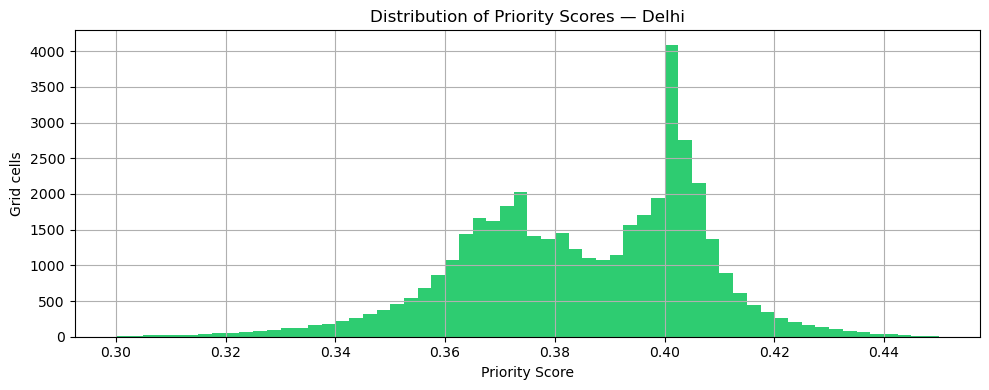

In [5]:
# Score distribution
import matplotlib.pyplot as plt
final_df['Greenspace_score'].hist(bins=60, figsize=(10,4), color='#2ecc71')
plt.title('Distribution of Priority Scores — Delhi')
plt.xlabel('Priority Score')
plt.ylabel('Grid cells')
plt.tight_layout()
plt.show()

In [6]:
# Spatial scatter — quick preview
import plotly.express as px
fig = px.scatter_mapbox(
    final_df.nlargest(500, 'Greenspace_score'),
    lat='Latitude', lon='Longitude',
    color='Greenspace_score', size='Greenspace_score',
    color_continuous_scale='Turbo', opacity=0.6,
    zoom=11, center=dict(lat=28.6139, lon=77.2090),
    mapbox_style='carto-positron',
    title='Top 500 Priority Zones — Delhi'
)
fig.update_layout(height=550, margin=dict(l=10,r=10,t=40,b=10))
fig.show()

## 4 — Final schema check

Expected columns consumed by `app.py`:

| Column | Description |
|--------|-------------|
| `Latitude`, `Longitude` | WGS-84 grid cell centroid |
| `Greenspace_score` | Priority score (higher = more suitable) |
| `penalty_reward` | Land feasibility multiplier |
| `AQ_score` | Normalised air-quality score |
| `PM25`, `PM10`, `NO2` | CPCB pollutant concentrations |
| `Pop_density` | WorldPop population per cell |
| `Heat_LST` | MODIS summer mean land-surface temperature (K) |
| `Building_Density` | Google Open Buildings footprint fraction |
| `Distance_Nearest_Greenspace` | Haversine km to nearest 3 OSM parks |
| `Green_Space` | 1 if OSM park/garden/forest in cell |
| `Water`, `Building`, `Airport`, `Railway` | Binary land-cover flags |
| `Hospital`, `School` | Binary OSM POI flags |
| `Bare_Land`, `Cropland`, `Wetland` | Binary WorldCover flags |

In [7]:
required_cols = [
    'Latitude','Longitude','Greenspace_score','penalty_reward',
    'AQ_score','PM25','PM10','NO2','Pop_density','Heat_LST',
    'Building_Density','Distance_Nearest_Greenspace','Green_Space',
    'Water','Building','Airport','Railway','Hospital','School',
    'Bare_Land','Cropland','Wetland'
]
missing = [c for c in required_cols if c not in final_df.columns]
if missing:
    print('⚠️  Missing columns:', missing)
else:
    print('✅  All required columns present.')

final_df[required_cols].describe()

✅  All required columns present.


,Latitude,Longitude,Greenspace_score,penalty_reward,AQ_score,PM25,PM10,NO2,Pop_density,Heat_LST,...,Green_Space,Water,Building,Airport,Railway,Hospital,School,Bare_Land,Cropland,Wetland
count,42299.000000,42299.000000,42299.000000,42299.0,42299.000000,42299.000000,42299.000000,42299.000000,42299.0,42299.0,...,42299.0,42299.0,42299.0,42299.0,42299.0,42299.0,42299.0,42299.0,42299.0,42299.0
mean,28.641073,77.095612,0.385311,1.0,0.568739,84.621723,137.721883,36.889588,0.0,305.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.138213,0.146864,0.021369,0.0,0.142463,3.345951,4.799792,1.497631,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,28.402425,76.840020,0.300000,1.0,0.000000,71.289199,118.418794,31.124970,0.0,305.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,28.521823,76.968397,0.369933,1.0,0.466222,82.215106,134.262655,35.824687,0.0,305.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,28.641187,77.095515,0.387757,1.0,0.585045,84.996525,138.301946,37.004222,0.0,305.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,28.760683,77.222886,0.401946,1.0,0.679642,87.204835,141.597045,37.933926,0.0,305.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,28.880000,77.349995,0.450000,1.0,1.000000,94.827473,151.762839,41.914881,0.0,305.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5 — Save final_df.csv

In [8]:
save_path = ROOT_FOLDER_PATH + '/final_df.csv'
final_df.to_csv(save_path, index=True)
size_mb = final_df.memory_usage(deep=True).sum() / 1e6
print(f'Saved → {save_path}  ({size_mb:.1f} MB in memory)')

Saved → /Users/utkarshsinha/Downloads/Paryavaran/final_df.csv  (8.8 MB in memory)


## 6 — (Optional) Upload to S3

In [9]:
# from helpers import upload_df_to_s3
# upload_df_to_s3(bucket='your-bucket', df=final_df, key='paryavaran/final_df.csv')